# Practica: limpieza y analisis de empleados

En esta actividad van a trabajar con el archivo `dataset.csv`.

El objetivo es detectar problemas en el dataset, limpiarlo usando `pandas` y responder preguntas puntuales a partir de los datos ya corregidos.

Al finalizar, deben entregar este notebook completo y exportar el dataset limpio.

## Objetivos

- Cargar un archivo CSV con `pandas`.
- Explorar la estructura general del dataset.
- Detectar valores faltantes, formatos inconsistentes y datos atipicos.
- Limpiar columnas numericas, categoricas y de fecha.
- Crear un dataset final limpio.
- Responder preguntas de analisis usando el dataset limpio.
- Exportar el resultado final.

## 1. Importacion de librerias

Importen las librerias necesarias para trabajar con datos.

In [123]:
# TODO: importar pandas con el alias pd.
# TODO: importar numpy con el alias np.
import pandas as pd
import numpy as np

## 2. Carga del dataset

Carguen el archivo `empleados_empresa_sucio.csv` en un DataFrame llamado `df`.

In [124]:
# TODO: leer el archivo dataset.csv con pandas.
# TODO: guardar el resultado en una variable llamada df.
df = pd.read_csv('dataset.csv')
# TODO: mostrar las primeras filas del DataFrame.
df.head()


,ID,Nombre_Completo,Edad,Genero,Ingresos,Domicilio,Lugar_Trabajo,Obra_Social,Fecha_Ingreso
0,1,laura nez,NaN,f,471493.0,Calle 6 # 570,El Colorado,Pami,2023-09-01
1,2,Carlos Prez,48,masculino,320995.0,Calle 79 # 278,Unknown,Iasep,2023-05-24
2,3,sofa lpez,40,masculino,$736519,Calle 56 # 493,Clorinda,Ninguna,2/6/2023
3,4,jose Daz,33,F,797863.0,Calle 76 N° 479,Formosa Capital,Osde,2023-12-19
4,5,Maria Lpez,22,FEM,457939.0,Calle 53 # 534,Clorinda,Osde,26/3/2023


## 3. Exploracion inicial

Respondan estas preguntas observando el dataset:

1. Cuantas filas y columnas tiene el dataset?
  - Tiene 150 filas y 9 columnas
2. Que columnas contiene?
  - Tiene las columnas: 'ID', 'Nombre_Completo', 'Edad', 'Genero', 'Ingresos', 'Domicilio',
       'Lugar_Trabajo', 'Obra_Social', 'Fecha_Ingreso'],
      dtype='object'
3. Que tipo de dato tiene cada columna?
  -   ID: int64

      Nombre_Completo	object

      Edad	object

      Genero	object

      Ingresos	object

      Domicilio	object

      Lugar_Trabajo	object

      Obra_Social	object

      Fecha_Ingreso	object
    

4. Hay valores faltantes?
  - Sí, hay 42 datos nulos en total

5. Que problemas detectan a simple vista?
  - Algunos problema que se puede ver es que hay datos faltantes pero no duplicados, pero el tipo de datos no son limpios ya que hay campos en donde el formato no son iguales como nombres o genero

In [125]:
# TODO: mostrar cuantas filas y columnas tiene el dataset.
df.shape

(150, 9)

In [126]:
# TODO: mostrar informacion general del DataFrame: columnas,
# tipos de datos y valores no nulos.
df.columns

df.dtypes

df.isnull().sum()

,0
ID,0
Nombre_Completo,0
Edad,26
Genero,16
Ingresos,0
Domicilio,0
Lugar_Trabajo,0
Obra_Social,0
Fecha_Ingreso,0


In [127]:
# TODO: calcular cuantos valores faltantes hay en cada columna.
df.duplicated().sum()
df[df.duplicated()]

,ID,Nombre_Completo,Edad,Genero,Ingresos,Domicilio,Lugar_Trabajo,Obra_Social,Fecha_Ingreso


Escriban aca sus primeras observaciones:

- Observacion 1: El tipo de dato no es consistente
- Observacion 2: Hay muchos datos nulos
- Observacion 3: No haya columnas repetidas

## 4. Crear una copia de trabajo

Antes de limpiar los datos, creen una copia del DataFrame original llamada `df_limpio`.

In [128]:
# TODO: crear una copia del DataFrame original llamada df_limpio.
# TODO: mostrar las primeras filas de df_limpio.
df_limpio = df.copy()
df_limpio.head()

,ID,Nombre_Completo,Edad,Genero,Ingresos,Domicilio,Lugar_Trabajo,Obra_Social,Fecha_Ingreso
0,1,laura nez,NaN,f,471493.0,Calle 6 # 570,El Colorado,Pami,2023-09-01
1,2,Carlos Prez,48,masculino,320995.0,Calle 79 # 278,Unknown,Iasep,2023-05-24
2,3,sofa lpez,40,masculino,$736519,Calle 56 # 493,Clorinda,Ninguna,2/6/2023
3,4,jose Daz,33,F,797863.0,Calle 76 N° 479,Formosa Capital,Osde,2023-12-19
4,5,Maria Lpez,22,FEM,457939.0,Calle 53 # 534,Clorinda,Osde,26/3/2023


## 5. Limpieza de nombres

La columna `Nombre_Completo` tiene nombres con mayusculas y minusculas mezcladas. Normalicen los nombres para que queden con formato de titulo.

Ejemplo: `laura nez` deberia quedar como `Laura Nez`.

In [129]:
# TODO: normalizar la columna Nombre_Completo para que los nombres queden con formato de titulo.
# TODO: revisar algunas filas para comprobar el resultado.

df_limpio['Nombre_Completo'] = df_limpio['Nombre_Completo'].str.title()
df_limpio.head()
# df.head()


,ID,Nombre_Completo,Edad,Genero,Ingresos,Domicilio,Lugar_Trabajo,Obra_Social,Fecha_Ingreso
0,1,Laura Nez,NaN,f,471493.0,Calle 6 # 570,El Colorado,Pami,2023-09-01
1,2,Carlos Prez,48,masculino,320995.0,Calle 79 # 278,Unknown,Iasep,2023-05-24
2,3,Sofa Lpez,40,masculino,$736519,Calle 56 # 493,Clorinda,Ninguna,2/6/2023
3,4,Jose Daz,33,F,797863.0,Calle 76 N° 479,Formosa Capital,Osde,2023-12-19
4,5,Maria Lpez,22,FEM,457939.0,Calle 53 # 534,Clorinda,Osde,26/3/2023


## 6. Limpieza de edad

La columna `Edad` puede tener valores faltantes y valores fuera de rango.

Tareas:

1. Convertir `Edad` a numerica.
2. Identificar edades imposibles o poco realistas. Por ejemplo, edades mayores a 100.
3. Reemplazar esas edades incorrectas por `NaN`.
4. Decidir como completar las edades faltantes: media, mediana u otro criterio.
5. Explicar por que eligieron ese criterio.

In [130]:
# TODO: convertir la columna Edad a tipo numerico.
# TODO: usar un metodo que transforme en NaN los valores que no puedan convertirse.
df_limpio['Edad'] = pd.to_numeric(df_limpio['Edad'], errors='coerce')
# TODO: mostrar estadisticas descriptivas de Edad.
df_limpio['Edad'].describe()
# TODO: detectar edades fuera de rango o poco realistas, por ejemplo mayores a 100.
edad_fueraRango = (df_limpio['Edad'] > 100) | (df_limpio['Edad'] < 0)
# TODO: mostrar las filas donde aparezcan esas edades.
df_limpio[edad_fueraRango]
# TODO: reemplazar las edades invalidas por NaN.
df_limpio.loc[edad_fueraRango, 'Edad'] = np.nan
# TODO: completar los valores faltantes de Edad usando media, mediana u otro criterio.
# Use la mediana porque es más robusta frente a valores extremos
df_limpio['Edad'] = df_limpio['Edad'].fillna(df_limpio['Edad'].median())
# TODO: verificar que ya no queden edades faltantes o explicar si se decide conservarlas.
print(df_limpio['Edad'].isna().sum())

0


Expliquen el criterio usado para completar las edades faltantes:

Respuesta:

## 7. Limpieza de genero

La columna `Genero` tiene varias formas de representar los mismos valores.

Por ejemplo:

- `M`, `m`, `masculino` podrian normalizarse como `Masculino`.
- `F`, `f`, `FEM` podrian normalizarse como `Femenino`.
- `O` puede quedar como `Otro`.

Tareas:

1. Revisar los valores unicos.
2. Crear un diccionario de reemplazo.
3. Normalizar la columna.
4. Decidir que hacer con los valores faltantes.

In [131]:
# TODO: revisar los valores unicos o frecuencias de la columna Genero, incluyendo valores faltantes.

df_limpio['Genero'].value_counts(dropna=False)


,count
Genero,
M,25
f,22
masculino,21
F,18
FEM,17
NaN,16
O,16
m,15


In [132]:
# TODO: crear un diccionario para unificar los valores de Genero.
# TODO: convertir M, m y masculino en Masculino.
# TODO: convertir F, f y FEM en Femenino.
# TODO: convertir O en Otro.
dic_gnro={ 'M': 'Masculino', 'm': 'Masculino', 'masculino': 'Masculino',
'F': 'Femenino', 'f': 'Femenino', 'FEM': 'Femenino',
'O': 'Otro'}
#Normalizamos
df_limpio['Genero'] = df_limpio['Genero'].replace(dic_gnro)
# TODO: decidir que hacer con los valores faltantes.
#en este caso decidi que los valores fantantes serán 'Desconocido'
df_limpio['Genero'] = df_limpio['Genero'].fillna('Desconocido')
# TODO: revisar las frecuencias finales.
df_limpio['Genero'].value_counts(dropna=False)

,count
Genero,
Masculino,61
Femenino,57
Desconocido,16
Otro,16


## 8. Limpieza de ingresos

La columna `Ingresos` contiene valores numericos, valores con simbolo `$` y textos como `not_available`.

Tareas:

1. Quitar simbolos que no correspondan.
2. Convertir la columna a numerica.
3. Detectar valores faltantes generados por la conversion.
4. Decidir como completar o tratar esos valores.

In [133]:
# TODO: observar ejemplos de la columna Ingresos antes de limpiarla.
# TODO: identificar simbolos, textos o formatos que impiden tratarla como numero.
df_limpio['Ingresos'].value_counts(dropna=False).head(20)
# TODO: quitar simbolos como $ de la columna Ingresos.
df_limpio['Ingresos'] = df_limpio['Ingresos'].astype(str).str.replace('$', '', regex=False).str.strip()
# TODO: convertir Ingresos a tipo numerico.
# TODO: transformar en NaN los valores que no puedan convertirse.
df_limpio['Ingresos'] = pd.to_numeric(df_limpio['Ingresos'], errors='coerce')
# TODO: mostrar estadisticas descriptivas de Ingresos.
df_limpio['Ingresos'].describe()



,Ingresos
count,140.000000
mean,611078.757143
std,168524.227776
min,302870.000000
25%,457309.500000
50%,620156.500000
75%,747801.750000
max,899045.000000


In [134]:
# TODO: contar cuantos valores faltantes quedaron en Ingresos despues de la conversion.
print(df_limpio['Ingresos'].isna().sum())
# TODO: decidir si se completan, se eliminan o se conservan como faltantes.
#decidi completas con la mediana ya que es menos sensible o outliers
df_limpio['Ingresos'] = df_limpio['Ingresos'].fillna(df_limpio['Ingresos'].median())

10


In [135]:
print(df_limpio['Ingresos'].isna().sum())

0


## 9. Limpieza de lugar de trabajo

La columna `Lugar_Trabajo` contiene valores como `Unknown`.

Tareas:

1. Revisar la frecuencia de cada lugar.
2. Reemplazar `Unknown` por `NaN` o por una categoria como `Sin dato`.
3. Justificar la decision.

In [136]:
# TODO: revisar la frecuencia de cada valor en Lugar_Trabajo.
# TODO: identificar si existen valores como Unknown u otros equivalentes a sin dato.
df_limpio['Lugar_Trabajo'].value_counts(dropna=False)


,count
Lugar_Trabajo,
Piran,28
Las Lomitas,27
El Colorado,25
Unknown,24
Formosa Capital,24
Clorinda,22


In [137]:
# TODO: reemplazar Unknown en Lugar_Trabajo por NaN o por una categoria como Sin dato.
df_limpio['Lugar_Trabajo'] = df_limpio['Lugar_Trabajo'].replace('Unknown', 'Sin dato')
# TODO: revisar nuevamente las frecuencias para confirmar el cambio.
df_limpio['Lugar_Trabajo'].value_counts(dropna=False)


,count
Lugar_Trabajo,
Piran,28
Las Lomitas,27
El Colorado,25
Sin dato,24
Formosa Capital,24
Clorinda,22


Justificacion:
Elegí "Sin dato" porque es una categoría válida, es visible en los gráficos y tablas. NaN es mejor para columnas numéricas

## 10. Limpieza de fechas

La columna `Fecha_Ingreso` tiene fechas con distintos formatos.

Tareas:

1. Convertir `Fecha_Ingreso` a tipo fecha con `pd.to_datetime()`.
2. Revisar si quedaron valores nulos.
3. Crear una columna nueva llamada `Anio_Ingreso`.
4. Crear una columna nueva llamada `Mes_Ingreso`.

In [138]:
# TODO: convertir Fecha_Ingreso a tipo fecha usando pandas.
# TODO: contemplar que hay fechas escritas con distintos formatos.
df_limpio['Fecha_Ingreso'] = pd.to_datetime(df_limpio['Fecha_Ingreso'], dayfirst=True, errors='coerce')
# TODO: revisar si quedaron fechas nulas despues de la conversion.
print(df_limpio['Fecha_Ingreso'].isna().sum())


106


In [139]:
# TODO: crear una columna Anio_Ingreso a partir de Fecha_Ingreso.
df_limpio['Anio_Ingreso'] = df_limpio['Fecha_Ingreso'].dt.year
# TODO: crear una columna Mes_Ingreso a partir de Fecha_Ingreso.
df_limpio['Mes_Ingreso'] = df_limpio['Fecha_Ingreso'].dt.month
# TODO: mostrar algunas filas con las tres columnas para comprobar el resultado.
df_limpio[['Fecha_Ingreso', 'Anio_Ingreso', 'Mes_Ingreso']].head(10)


,Fecha_Ingreso,Anio_Ingreso,Mes_Ingreso
0,2023-01-09,2023.0,1.0
1,NaT,NaN,NaN
2,NaT,NaN,NaN
3,NaT,NaN,NaN
4,NaT,NaN,NaN
5,NaT,NaN,NaN
6,NaT,NaN,NaN
7,2023-07-01,2023.0,7.0
8,NaT,NaN,NaN
9,NaT,NaN,NaN


## 11. Revision final del dataset limpio

Antes de responder las preguntas, revisen que el dataset haya quedado consistente.

In [140]:
# TODO: revisar la informacion general del dataset limpio.
df_limpio.info()
# TODO: verificar que los tipos de datos sean adecuados despues de la limpieza.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   ID               150 non-null    int64         
 1   Nombre_Completo  150 non-null    object        
 2   Edad             150 non-null    float64       
 3   Genero           150 non-null    object        
 4   Ingresos         150 non-null    float64       
 5   Domicilio        150 non-null    object        
 6   Lugar_Trabajo    150 non-null    object        
 7   Obra_Social      150 non-null    object        
 8   Fecha_Ingreso    44 non-null     datetime64[ns]
 9   Anio_Ingreso     44 non-null     float64       
 10  Mes_Ingreso      44 non-null     float64       
dtypes: datetime64[ns](1), float64(4), int64(1), object(5)
memory usage: 13.0+ KB


In [141]:
# TODO: revisar cuantos valores faltantes quedan en cada columna del dataset limpio.
df_limpio.isnull().sum()

,0
ID,0
Nombre_Completo,0
Edad,0
Genero,0
Ingresos,0
Domicilio,0
Lugar_Trabajo,0
Obra_Social,0
Fecha_Ingreso,106
Anio_Ingreso,106


In [142]:
# TODO: mostrar las primeras filas del dataset limpio para una revision visual final.
df_limpio.head()

,ID,Nombre_Completo,Edad,Genero,Ingresos,Domicilio,Lugar_Trabajo,Obra_Social,Fecha_Ingreso,Anio_Ingreso,Mes_Ingreso
0,1,Laura Nez,40.0,Femenino,471493.0,Calle 6 # 570,El Colorado,Pami,2023-01-09,2023.0,1.0
1,2,Carlos Prez,48.0,Masculino,320995.0,Calle 79 # 278,Sin dato,Iasep,NaT,NaN,NaN
2,3,Sofa Lpez,40.0,Masculino,736519.0,Calle 56 # 493,Clorinda,Ninguna,NaT,NaN,NaN
3,4,Jose Daz,33.0,Femenino,797863.0,Calle 76 N° 479,Formosa Capital,Osde,NaT,NaN,NaN
4,5,Maria Lpez,22.0,Femenino,457939.0,Calle 53 # 534,Clorinda,Osde,NaT,NaN,NaN


## 12. Preguntas de analisis

Usen el dataset limpio para responder las siguientes preguntas. Cada respuesta debe incluir el codigo utilizado y una breve interpretacion en texto.

### Pregunta 1

Cual es el promedio de edad de los empleados?

In [143]:
# TODO: calcular el promedio de edad de los empleados usando el dataset limpio.
df_limpio['Edad'].mean()

np.float64(41.68)

Interpretacion: El promedio de la edad de los empleados es de 41.68

Respuesta: 41.68

### Pregunta 2

Cual es la media de ingresos?

In [144]:
# TODO: calcular la media de ingresos usando el dataset limpio.
df_limpio['Ingresos'].mean()


np.float64(611683.94)

Interpretacion: La media de los ingresos del dataset limpio es de 611683.94

Respuesta: 611683.94

### Pregunta 3

Que obra social es la que mas se repite?

In [145]:
# TODO: identificar que obra social aparece con mayor frecuencia.
# TODO: mostrar tambien la cantidad de empleados asociada.
df_limpio['Obra_Social'].value_counts().head(1)

,count
Obra_Social,
Osde,40


Interpretacion:

Respuesta:

### Pregunta 4

Cuantos empleados hay por genero?

In [146]:
# TODO: contar cuantos empleados hay por cada categoria de Genero.


### Pregunta 5

Cual es el lugar de trabajo con mayor cantidad de empleados?

In [147]:
# TODO: identificar el lugar de trabajo con mayor cantidad de empleados.
df_limpio['Lugar_Trabajo'].value_counts().head(1)


,count
Lugar_Trabajo,
Piran,28


### Pregunta 6

Cual es el ingreso promedio por genero?

In [148]:
# TODO: calcular el ingreso promedio agrupado por Genero.
df_limpio.groupby('Genero')['Ingresos'].mean()

,Ingresos
Genero,
Desconocido,611870.031250
Femenino,579284.956140
Masculino,622141.319672
Otro,687050.468750


### Pregunta 7

Cual es la edad promedio por lugar de trabajo?

In [149]:
# TODO: calcular la edad promedio agrupada por Lugar_Trabajo.
df_limpio.groupby('Lugar_Trabajo')['Edad'].mean()


,Edad
Lugar_Trabajo,
Clorinda,40.590909
El Colorado,40.840000
Formosa Capital,42.375000
Las Lomitas,39.407407
Piran,43.500000
Sin dato,43.291667


### Pregunta 8

Cuantos empleados ingresaron por mes?

In [150]:
# TODO: contar cuantos empleados ingresaron en cada mes.
# TODO: ordenar los resultados de forma clara.
df_limpio['Mes_Ingreso'].value_counts().sort_index()

,count
Mes_Ingreso,
1.0,7
2.0,3
3.0,3
4.0,6
5.0,3
6.0,1
7.0,6
8.0,3
9.0,4


### Pregunta 9

Cual es el empleado con mayor ingreso? Que datos tiene?

In [151]:
# TODO: encontrar el empleado con mayor ingreso.
# TODO: mostrar sus datos completos o las columnas mas importantes.
emp_maxIngreso= df_limpio[df_limpio['Ingresos'] == df_limpio['Ingresos'].max()]
emp_maxIngreso

,ID,Nombre_Completo,Edad,Genero,Ingresos,Domicilio,Lugar_Trabajo,Obra_Social,Fecha_Ingreso,Anio_Ingreso,Mes_Ingreso
134,135,Lucas Nez,55.0,Femenino,899045.0,Calle 87 N° 341,Sin dato,Iasep,2023-01-03,2023.0,1.0


### Pregunta 10

Existe alguna relacion entre edad e ingresos? Calculen o grafiquen algo que ayude a responder.

Correlación entre edad e ingresos: 0.05
Correlación: 0.05
Mediana de Edad: 40.0
Cantidad de empleados con Edad == 40: 47


<Axes: title={'center': 'Edad vs Ingresos (sin imputados)'}, xlabel='Edad', ylabel='Ingresos'>

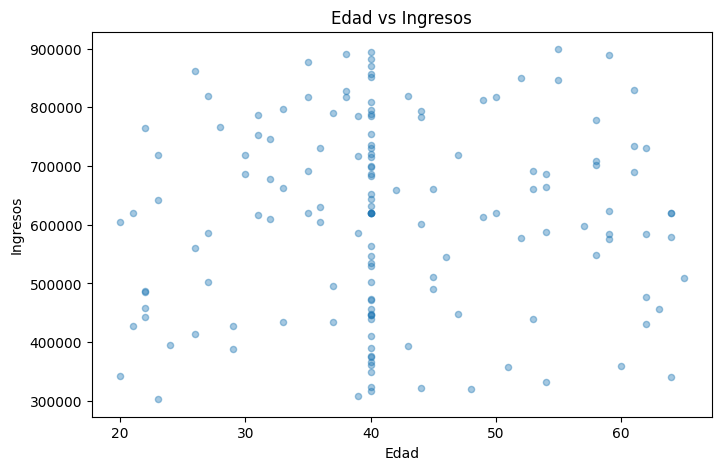

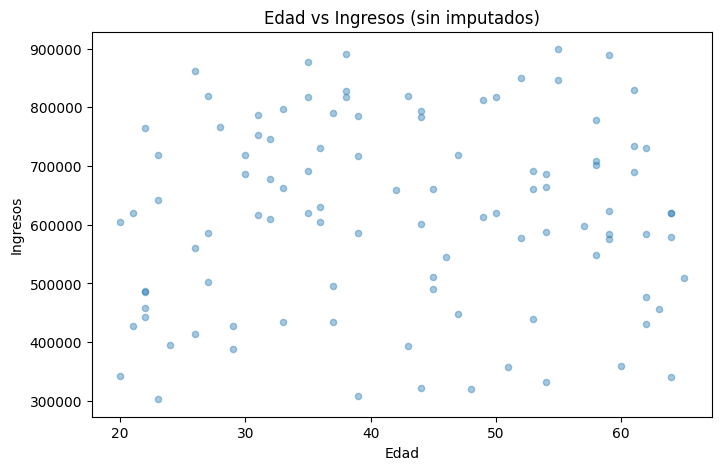

In [152]:
# TODO: analizar si existe relacion entre Edad e Ingresos.
# TODO: pueden usar correlacion, una tabla resumen o un grafico de dispersion.
correlacion = df_limpio['Edad'].corr(df_limpio['Ingresos'])
print(f"Correlación entre edad e ingresos: {correlacion:.2f}")
# TODO: escribir una breve interpretacion del resultado.
df_limpio.plot.scatter(x='Edad', y='Ingresos', alpha=0.4, figsize=(8, 5), title='Edad vs Ingresos')

print(f"Correlación: {df_limpio['Edad'].corr(df_limpio['Ingresos']):.2f}")
print(f"Mediana de Edad: {df_limpio['Edad'].median()}")
print(f"Cantidad de empleados con Edad == 40: {(df_limpio['Edad'] == 40).sum()}")

# Graficar solo edades que no sean la mediana imputada
df_sin_imputados = df_limpio[df_limpio['Edad'] != df_limpio['Edad'].median()]
df_sin_imputados.plot.scatter(x='Edad', y='Ingresos', alpha=0.4, figsize=(8, 5), title='Edad vs Ingresos (sin imputados)')

# La correlación entre Edad e Ingresos es cercana a 0, lo que indica que
# no existe una relación lineal entre ambas variables. El gráfico de
# dispersión confirma que los ingresos se distribuyen de forma aleatoria
# a lo largo de todos los rangos de edad, sin una tendencia clara.


## 13. Preguntas extra

Elijan al menos 3 preguntas extra para responder:

1. Cual es la mediana de ingresos?
2. Cual es el ingreso minimo y el ingreso maximo?
3. Que porcentaje de empleados no tiene obra social?
4. Que obra social predomina en cada lugar de trabajo?
5. Cual es el promedio de ingresos por obra social?
6. Cuantos empleados tienen menos de 30 anios?
7. Cuantos empleados tienen 50 anios o mas?
8. En que mes hubo mas ingresos de empleados?
9. Hay nombres repetidos? Cuales?
10. Que columnas fueron mas dificiles de limpiar y por que?

In [153]:
# TODO: resolver una pregunta extra elegida de la lista.
# TODO: agregar una breve interpretacion del resultado.
# 2: Cual es el ingreso minimo y el ingreso maximo?
ingreso_min = df_limpio['Ingresos'].min()
ingreso_max = df_limpio['Ingresos'].max()
print(f"Ingreso mínimo: ${ingreso_min:,.0f}")
print(f"Ingreso máximo: ${ingreso_max:,.0f}")
# Interpretacion: permite identificar la brecha salarial dentro de la empresa.

Ingreso mínimo: $302,870
Ingreso máximo: $899,045


In [154]:
# TODO: resolver una segunda pregunta extra elegida de la lista.
# TODO: agregar una breve interpretacion del resultado.
# 6: Cuantos empleados tienen menos de 30 anios?
menores_30 = (df_limpio['Edad'] < 30).sum()
print(f"Empleados menores de 30 años: {menores_30}")
# Interpretacion: indica que proporcion de la dotacion es personal joven.

Empleados menores de 30 años: 22


In [155]:
# TODO: resolver una tercera pregunta extra elegida de la lista.
# TODO: agregar una breve interpretacion del resultado.
# 9: Hay nombres repetidos? Cuales?
repetidos = df_limpio[df_limpio.duplicated(subset='Nombre_Completo', keep=False)]
print(f"Nombres repetidos: {repetidos['Nombre_Completo'].nunique()}")
repetidos[['Nombre_Completo']].value_counts()
# Interpretacion: los nombres repetidos pueden ser homonimos o registros duplicados
# que habria que revisar junto con otras columnas como DNI o legajo.

Nombres repetidos: 48


,count
Nombre_Completo,
Laura Torres,6
Carlos Gimenez,4
Pedro Duarte,4
Sofa Torres,4
Laura Nez,4
Laura Gmez,4
Juan Prez,4
Lucas Fernndez,4
Luca Torres,3


## 14. Exportacion final

Exporten el dataset limpio en formato CSV con el nombre `empleados_empresa_limpio.csv`.

Ademas, entreguen este notebook con todas las celdas ejecutadas y las respuestas escritas.

In [156]:
# TODO: exportar el DataFrame limpio a un archivo llamado empleados_empresa_limpio.csv.
# TODO: asegurarse de no exportar el indice como una columna adicional.
df_limpio.to_csv('empleados_empresa_limpio.csv', index=False)

print("Archivo exportado correctamente!")
print(f"Filas exportadas:   {df_limpio.shape[0]}")
print(f"Columnas exportadas: {df_limpio.shape[1]}")

Archivo exportado correctamente!
Filas exportadas:   150
Columnas exportadas: 11


## 15. Reflexion final

Respondan brevemente:

1. Que problemas tenia el dataset original?
- **Nombre_Completo**: nombres en mayúsculas, minúsculas y formatos mixtos.
- **Edad**: valores como texto, edades negativas y mayores a 100.
- **Genero**: múltiples formas para el mismo valor (M, m, masculino, FEM, etc.).
- **Ingresos**: símbolos como `$` y textos como `not_available`.
- **Lugar_Trabajo**: valores `Unknown` sin significado claro.
- **Fecha_Ingreso**: fechas con distintos formatos mezclados.
2. Que decisiones tomaron para limpiar los datos?
- Usamos la **mediana** para completar Edad e Ingresos porque es más robusta frente a valores extremos.
- Reemplazamos `Unknown` por `Sin dato` para conservar la fila sin perder información.
- Usamos `errors='coerce'` en las conversiones para transformar valores inválidos en NaN de forma controlada.
- Normalizamos Genero con un diccionario de reemplazos para unificar categorías.
3. Que informacion interesante encontraron?
- No existe relación entre Edad e Ingresos: el salario no depende de la edad del empleado.
- La concentración de edades en 40 años reveló que muchos valores fueron imputados con la mediana.
- Hay nombres repetidos que podrían ser duplicados reales o simplemente homónimos.
4. Que cambiarian si recibieran un dataset parecido en un trabajo real?
- Antes de imputar con la mediana, analizaríamos si los datos faltantes siguen algún patrón (por área, por fecha, etc.).
- Consultaríamos con el equipo de RRHH el significado exacto de valores como `Unknown` o `not_available` antes de reemplazarlos.
- Usaríamos un identificador único como DNI o legajo para detectar duplicados reales con más precisión.
- Documentaríamos cada decisión de limpieza en un registro formal para que sea reproducible.